# Mobility Analysis — TVDE Lisbon

## Overview
This notebook analyses the geographic patterns of ride origins and
destinations across the Lisbon metropolitan area, using postal code
areas (first 4 digits) as geographic units.

## Data Source
- **Input:** tvde_rides_clean.csv (cleaned in notebook 01)
- **Rides analysed:** 1,545 total | 1,481 within working hours (95.9%)
- **Geographic units:** Postal code areas (first 4 digits of XXXX-XXX format)
- **Unique origin areas:** 71 | **Unique destination areas:** 78

## Analysis Structure
- **Group 1:** Geographic concentration — top origin and destination postal codes
- **Group 2:** Mobility flows — most frequent origin → destination pairs
- **Group 3:** Earnings by postal code area — which zones generate most value
- **Group 4:** Temporal patterns — how hotspots change by time period and day type

## Methodology Note
Postal codes are grouped by their first 4 digits to create meaningful
geographic areas. The full 7-digit code (XXXX-XXX) has too many unique
values for reliable pattern analysis. The 4-digit grouping corresponds
to recognisable urban zones within the Lisbon metropolitan area.

Geographic visualisation (interactive map) is available in the
Power BI dashboard — page 4 "Geographic Concentration".

In [3]:
# Environment check — mobility notebook

libraries = ["pandas", "matplotlib", "numpy", "folium", "branca"]

for lib in libraries:
    try:
        module = __import__(lib)
        version = getattr(module, "__version__", "unknown")
        print(f"✅ {lib} — installed (version {version})")
    except ImportError:
        print(f"❌ {lib} — NOT installed")

✅ pandas — installed (version 2.3.3)
✅ matplotlib — installed (version 3.10.8)
✅ numpy — installed (version 2.4.1)
✅ folium — installed (version 0.20.0)
✅ branca — installed (version 0.8.2)


In [14]:
# MOBILITY ANALYSIS — TVDE Lisbon
# Analysing geographic patterns of ride origins and destinations

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter

# Load cleaned data
df = pd.read_csv("../data/processed/tvde_rides_clean.csv")

# Fix naming consistency
df["Platform"] = df["Platform"].str.strip().str.title()
df["Category"] = df["Category"].str.strip().str.title()

# Extract 4-digit area code from postal codes
df["Origin_Area"] = df["Origin_PostCode"].str[:4]
df["Dest_Area"] = df["Dest_PostCode"].str[:4]

print(f"Total rides: {len(df)}")
print(f"Unique origin postal codes areas: {df['Origin_Area'].nunique()}")
print(f"Unique destination postal codes areas: {df['Dest_Area'].nunique()}")
print(f"All postal codes areas combined: {pd.concat([df['Origin_Area'], df['Dest_Area']]).nunique()}")

Total rides: 1545
Unique origin postal codes areas: 71
Unique destination postal codes areas: 78
All postal codes areas combined: 82


In [12]:
# GROUP 1 — Geographic concentration
# Top 10 origin and destination areas side by side

top_origins = (df["Origin_Area"]
               .value_counts()
               .head(10)
               .reset_index())
top_origins.columns = ["Origin_Area", "Origin_Rides"]

top_destinations = (df["Dest_Area"]
                    .value_counts()
                    .head(10)
                    .reset_index())
top_destinations.columns = ["Dest_Area", "Dest_Rides"]

# Side by side comparison
comparison = pd.concat([top_origins, top_destinations], axis=1)

print("TOP 10 postal codes AREAS — Origin vs Destination")
print("=" * 55)
print(f"{'Rank':<6} {'Origin':>10} {'Rides':>8}   {'Destination':>12} {'Rides':>8}")
print("-" * 55)
for i, row in comparison.iterrows():
    print(f"{i+1:<6} {row['Origin_Area']:>10} {row['Origin_Rides']:>8}   "
          f"{row['Dest_Area']:>12} {row['Dest_Rides']:>8}")
print("=" * 55)

TOP 10 postal codes AREAS — Origin vs Destination
Rank       Origin    Rides    Destination    Rides
-------------------------------------------------------
1            1300      155           1300      167
2            1500      142           1500      150
3            1600      104           1700      134
4            1700      103           1600       92
5            1400       94           1495       91
6            1495       88           1400       72
7            1990       64           2790       69
8            2790       60           2625       56
9            2615       48           1990       50
10           1050       47           1200       44


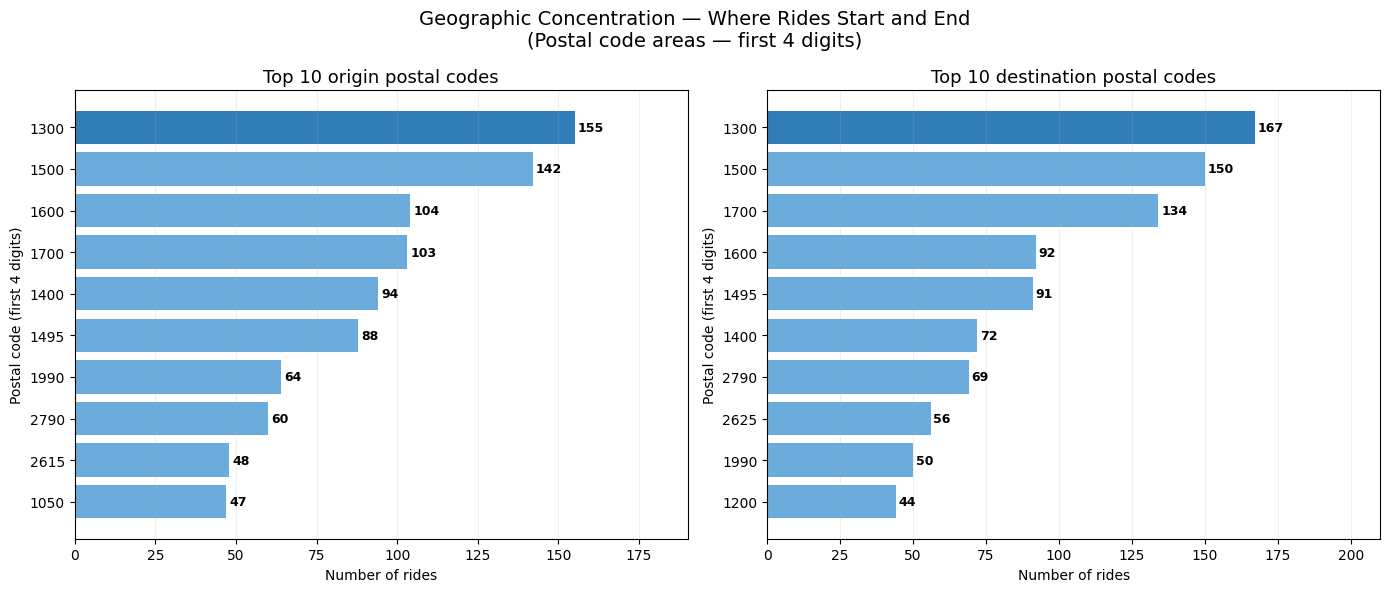

In [11]:
# GROUP 1 — Visual: Top 10 Origin vs Destination postal codes

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — Top 10 Origin postal codes
colors_origin = ["#1a6faf" if i == 0 else "#5ba3d9"
                 for i in range(len(top_origins))]

bars1 = ax1.barh(top_origins["Origin_Area"].astype(str)[::-1],
                 top_origins["Origin_Rides"][::-1],
                 color=colors_origin[::-1], alpha=0.9, edgecolor="none")

for bar, val in zip(bars1, top_origins["Origin_Rides"][::-1]):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f"{val}", va="center", fontsize=9, fontweight="bold")

ax1.set_title("Top 10 origin postal codes", fontsize=13)
ax1.set_xlabel("Number of rides", fontsize=10)
ax1.set_ylabel("Postal code (first 4 digits)", fontsize=10)
ax1.set_xlim(0, 190)
ax1.grid(True, alpha=0.2, axis="x")

# Chart 2 — Top 10 Destination postal codes
colors_dest = ["#1a6faf" if i == 0 else "#5ba3d9"
               for i in range(len(top_destinations))]

bars2 = ax2.barh(top_destinations["Dest_Area"].astype(str)[::-1],
                 top_destinations["Dest_Rides"][::-1],
                 color=colors_dest[::-1], alpha=0.9, edgecolor="none")

for bar, val in zip(bars2, top_destinations["Dest_Rides"][::-1]):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f"{val}", va="center", fontsize=9, fontweight="bold")

ax2.set_title("Top 10 destination postal codes", fontsize=13)
ax2.set_xlabel("Number of rides", fontsize=10)
ax2.set_ylabel("Postal code (first 4 digits)", fontsize=10)
ax2.set_xlim(0, 210)
ax2.grid(True, alpha=0.2, axis="x")

plt.suptitle("Geographic Concentration — Where Rides Start and End\n"
             "(Postal code areas — first 4 digits)",
             fontsize=14)
plt.tight_layout()
plt.savefig("../images/mobility_top10_postal_codes.png", dpi=150,
            bbox_inches="tight")
plt.show()

## Group 1 — Geographic Concentration

**Top 10 origin and destination postal code areas:**

| Rank | Origin PC | Rides | Destination PC | Rides |
|---|---|---|---|---|
| 1 | 1300 | 155 | 1300 | 167 |
| 2 | 1500 | 142 | 1500 | 150 |
| 3 | 1600 | 104 | 1700 | 134 |
| 4 | 1700 | 103 | 1600 | 92 |
| 5 | 1400 | 94 | 1495 | 91 |
| 6 | 1495 | 88 | 1400 | 72 |
| 7 | 1990 | 64 | 2790 | 69 |
| 8 | 2790 | 60 | 2625 | 56 |
| 9 | 2615 | 48 | 1990 | 50 |
| 10 | 1050 | 47 | 1200 | 44 |

**Interpretation:**
Postal codes 1300 and 1500 dominate both origins and destinations —
these central Lisbon zones are the core of TVDE mobility demand.
The top 5 origin areas are identical to the top 5 destination areas,
confirming that high-demand zones attract both outgoing and incoming rides.

**Key insight:**
Postal code 1700 rises from 4th in origins to 3rd in destinations —
more people arrive in this zone than depart, suggesting it is a
net destination zone (commercial or work-related activity).
Areas 1990 and 2615 are more prominent as origins than destinations —
typical of residential peripheral zones where people depart for
central areas.

In [15]:
# GROUP 2 — Mobility flows
# Most frequent origin → destination postal code pairs

# Create flow pairs
df["Flow"] = df["Origin_Area"] + " → " + df["Dest_Area"]

# Top 15 flows
top_flows = (df["Flow"]
             .value_counts()
             .head(15)
             .reset_index())
top_flows.columns = ["Flow", "Rides"]
top_flows["Origin_PostCode"] = top_flows["Flow"].str.split(" → ").str[0]
top_flows["Dest_PostCode"] = top_flows["Flow"].str.split(" → ").str[1]
top_flows["Is_Same_Area"] = (top_flows["Origin_PostCode"] ==
                              top_flows["Dest_PostCode"])

print("TOP 15 MOST FREQUENT MOBILITY FLOWS")
print("(Postal code areas — first 4 digits)")
print("=" * 60)
print(f"{'Rank':<6} {'Origin PC':<12} {'Dest PC':<12} "
      f"{'Rides':>8} {'Same Area':>12}")
print("-" * 60)
for i, row in top_flows.iterrows():
    same = "Yes" if row["Is_Same_Area"] else "No"
    print(f"{i+1:<6} {row['Origin_PostCode']:<12} "
          f"{row['Dest_PostCode']:<12} "
          f"{row['Rides']:>8} {same:>12}")
print("=" * 60)

same_area = df[df["Origin_Area"] == df["Dest_Area"]]
print(f"\nRides within same postal code area: {len(same_area)} "
      f"({len(same_area)/len(df)*100:.1f}%)")
print(f"Rides between different areas:      {len(df)-len(same_area)} "
      f"({(len(df)-len(same_area))/len(df)*100:.1f}%)")

TOP 15 MOST FREQUENT MOBILITY FLOWS
(Postal code areas — first 4 digits)
Rank   Origin PC    Dest PC         Rides    Same Area
------------------------------------------------------------
1      1500         1300               22           No
2      1300         1300               22          Yes
3      1300         1500               20           No
4      1300         1700               18           No
5      1500         1700               18           No
6      1400         1500               16           No
7      1600         1500               15           No
8      1700         1300               15           No
9      1600         1300               15           No
10     1990         2625               13           No
11     1300         1495               12           No
12     1300         2790               12           No
13     1500         1600               11           No
14     1070         1300               11           No
15     1495         1300               11

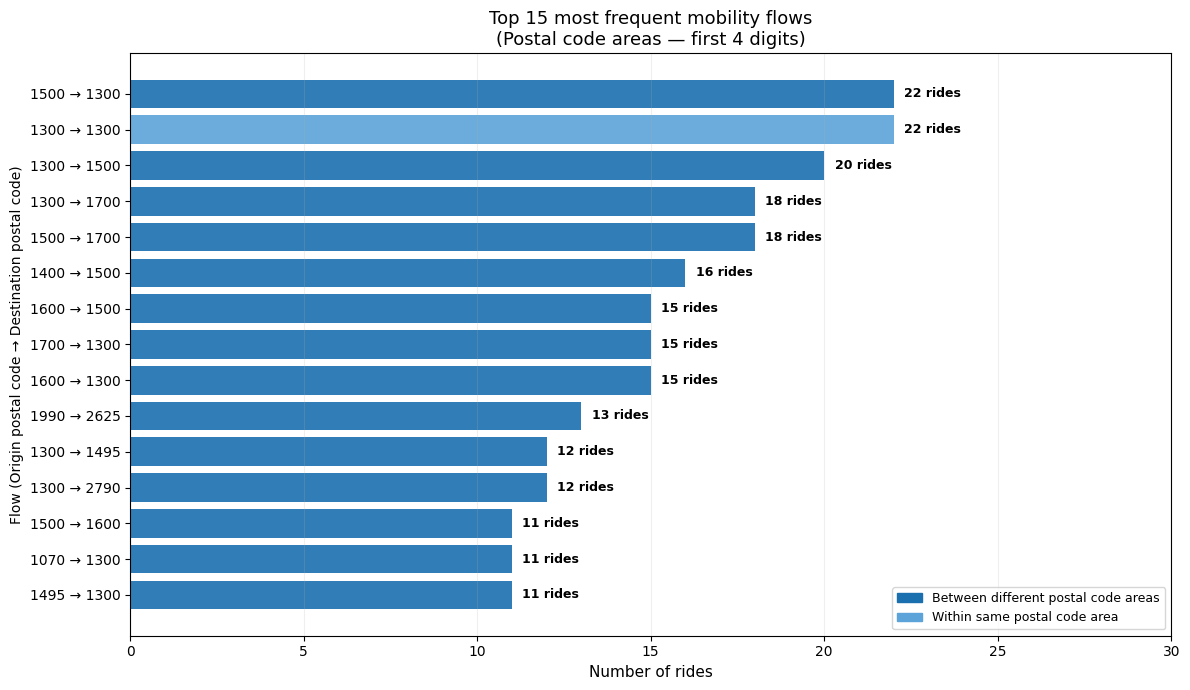

In [16]:
# GROUP 2 — Visual: Top 15 mobility flows

fig, ax = plt.subplots(figsize=(12, 7))

colors_flow = ["#1a6faf" if not same else "#5ba3d9"
               for same in top_flows["Is_Same_Area"]]

bars = ax.barh(top_flows["Flow"][::-1],
               top_flows["Rides"][::-1],
               color=colors_flow[::-1], alpha=0.9, edgecolor="none")

for bar, val in zip(bars, top_flows["Rides"][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val} rides", va="center", fontsize=9, fontweight="bold")

# Legend
same_patch = mpatches.Patch(color="#5ba3d9", label="Within same postal code area")
diff_patch = mpatches.Patch(color="#1a6faf", label="Between different postal code areas")
ax.legend(handles=[diff_patch, same_patch], fontsize=9, loc="lower right")

ax.set_title("Top 15 most frequent mobility flows\n"
             "(Postal code areas — first 4 digits)",
             fontsize=13)
ax.set_xlabel("Number of rides", fontsize=11)
ax.set_ylabel("Flow (Origin postal code → Destination postal code)", fontsize=10)
ax.set_xlim(0, 30)
ax.grid(True, alpha=0.2, axis="x")

plt.tight_layout()
plt.savefig("../images/mobility_top15_flows.png", dpi=150,
            bbox_inches="tight")
plt.show()

## Group 2 — Mobility Flows

**Top 15 most frequent origin → destination flows:**

| Rank | Flow | Rides | Same Area |
|---|---|---|---|
| 1 | 1500 → 1300 | 22 | No |
| 2 | 1300 → 1300 | 22 | Yes |
| 3 | 1300 → 1500 | 20 | No |
| 4 | 1300 → 1700 | 18 | No |
| 5 | 1500 → 1700 | 18 | No |
| 6 | 1400 → 1500 | 16 | No |
| 7 | 1600 → 1500 | 15 | No |
| 8 | 1700 → 1300 | 15 | No |
| 9 | 1600 → 1300 | 15 | No |
| 10 | 1990 → 2625 | 13 | No |

**Rides within same postal code area:** 79 (5.1%)
**Rides between different areas:** 1,466 (94.9%)

**Interpretation:**
94.9% of all rides connect different postal code areas, confirming
that TVDE in Lisbon is primarily an inter-neighbourhood mobility
service, not a local short-trip service.

**Key insight:**
The 1300 ↔ 1500 corridor is the most active in both directions
(22 rides each way), revealing a strong bidirectional demand between
these two central zones. Postal codes 1300, 1500 and 1700 form the
core mobility triangle of Lisbon — they appear as both origin and
destination in the majority of top flows.

The flow 1990 → 2625 is the only top-15 flow connecting the
northern periphery (Sacavém) to the western coast (Cascais area),
suggesting occasional but consistent demand on this corridor.

In [21]:
# GROUP 3 — Earnings by postal code area
# Which origin postal codes generate the most value per ride?

origin_earnings = df.groupby("Origin_Area").agg(
    total_rides=("Ride_ID", "count"),
    avg_earnings=("Driver_Earnings_EUR", "mean"),
    avg_eur_per_km=("Distance_Km", lambda x:
                    (df.loc[x.index, "Driver_Earnings_EUR"] / x).mean()),
    total_earnings=("Driver_Earnings_EUR", "sum")
).reset_index()

origin_earnings = origin_earnings[
    origin_earnings["total_rides"] >= 10
].sort_values("avg_earnings", ascending=False).reset_index(drop=True)

origin_earnings.index += 1
origin_earnings.columns = ["Postal Code", "Rides",
                            "Avg Earnings (€)", "Avg €/km",
                            "Total Earnings (€)"]
origin_earnings["Avg Earnings (€)"] = origin_earnings["Avg Earnings (€)"].round(2)
origin_earnings["Avg €/km"] = origin_earnings["Avg €/km"].round(2)
origin_earnings["Total Earnings (€)"] = origin_earnings["Total Earnings (€)"].round(2)

# Reorder columns — Avg Earnings first for clarity
origin_earnings = origin_earnings[["Postal Code", "Avg Earnings (€)",
                                    "Avg €/km", "Rides",
                                    "Total Earnings (€)"]]

dest_earnings = df.groupby("Dest_Area").agg(
    total_rides=("Ride_ID", "count"),
    avg_earnings=("Driver_Earnings_EUR", "mean"),
    total_earnings=("Driver_Earnings_EUR", "sum")
).reset_index()

dest_earnings = dest_earnings[
    dest_earnings["total_rides"] >= 10
].sort_values("avg_earnings", ascending=False).reset_index(drop=True)

dest_earnings.index += 1
dest_earnings.columns = ["Postal Code", "Rides",
                          "Avg Earnings (€)", "Total Earnings (€)"]
dest_earnings["Avg Earnings (€)"] = dest_earnings["Avg Earnings (€)"].round(2)
dest_earnings["Total Earnings (€)"] = dest_earnings["Total Earnings (€)"].round(2)

# Reorder columns — Avg Earnings first for clarity
dest_earnings = dest_earnings[["Postal Code", "Avg Earnings (€)",
                                "Rides", "Total Earnings (€)"]]

print("TOP 10 ORIGIN POSTAL CODES BY AVG EARNINGS PER RIDE")
print("(Minimum 10 rides for statistical relevance)")
display(origin_earnings.head(10))

print("\nTOP 10 DESTINATION POSTAL CODES BY AVG EARNINGS PER RIDE")
print("(Minimum 10 rides for statistical relevance)")
display(dest_earnings.head(10))

TOP 10 ORIGIN POSTAL CODES BY AVG EARNINGS PER RIDE
(Minimum 10 rides for statistical relevance)


,Postal Code,Avg Earnings (€),Avg €/km,Rides,Total Earnings (€)
1,2690,9.24,0.46,10,92.35
2,2785,9.19,0.58,10,91.86
3,2625,8.04,0.70,44,353.86
4,2780,7.97,0.81,18,143.49
5,2615,7.89,0.66,48,378.61
6,1100,7.65,0.91,25,191.29
7,2775,7.32,0.68,14,102.48
8,1700,7.08,0.87,103,729.67
9,1800,7.01,0.63,45,315.33
10,1990,6.81,0.68,64,435.61



TOP 10 DESTINATION POSTAL CODES BY AVG EARNINGS PER RIDE
(Minimum 10 rides for statistical relevance)


,Postal Code,Avg Earnings (€),Rides,Total Earnings (€)
1,2775,8.66,19,164.59
2,1200,8.60,44,378.50
3,1100,8.16,11,89.81
4,2615,8.16,16,130.55
5,1150,7.89,12,94.71
6,2780,7.66,18,137.83
7,2675,7.52,12,90.24
8,1900,7.46,14,104.43
9,1350,7.08,20,141.62
10,2625,6.94,56,388.44


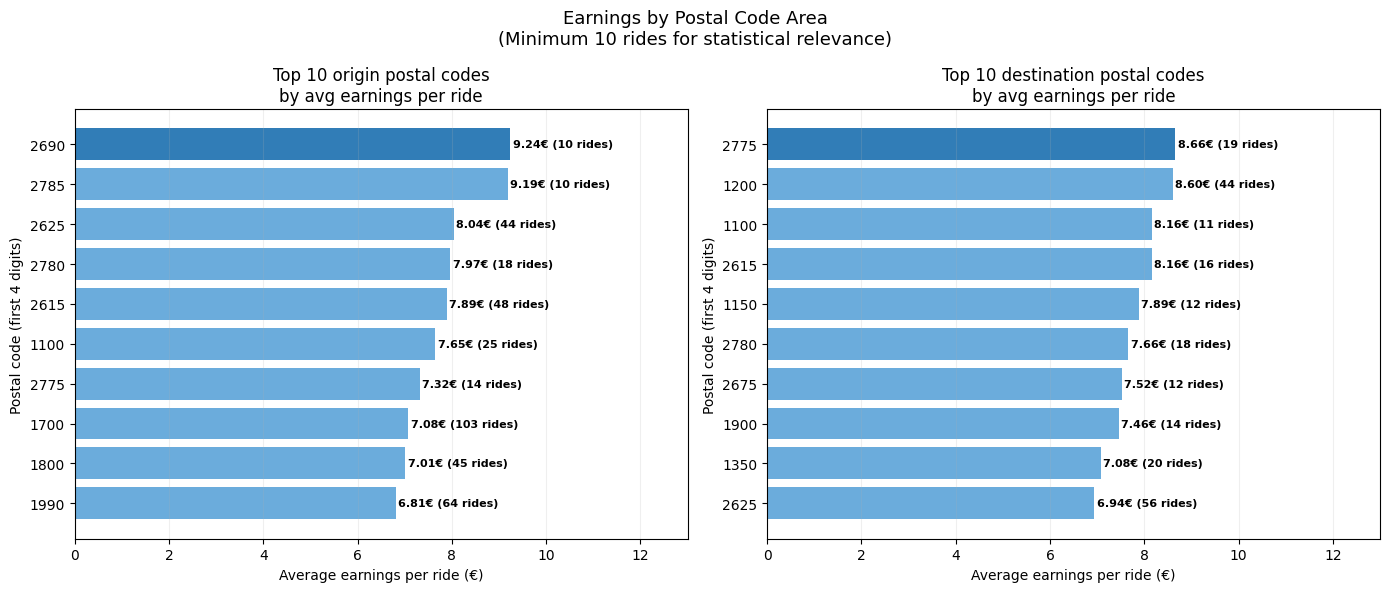

In [22]:
# GROUP 3 — Visual: Avg earnings by postal code area

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — Origin postal codes
origin_plot = origin_earnings.head(10).reset_index()
colors_orig = ["#1a6faf" if i == 0 else "#5ba3d9"
               for i in range(len(origin_plot))]

bars1 = ax1.barh(origin_plot["Postal Code"].astype(str)[::-1],
                 origin_plot["Avg Earnings (€)"][::-1],
                 color=colors_orig[::-1], alpha=0.9, edgecolor="none")

for bar, val, rides in zip(bars1,
                            origin_plot["Avg Earnings (€)"][::-1],
                            origin_plot["Rides"][::-1]):
    ax1.text(bar.get_width() + 0.05,
             bar.get_y() + bar.get_height()/2,
             f"{val:.2f}€ ({rides} rides)",
             va="center", fontsize=8, fontweight="bold")

ax1.set_title("Top 10 origin postal codes\nby avg earnings per ride",
              fontsize=12)
ax1.set_xlabel("Average earnings per ride (€)", fontsize=10)
ax1.set_ylabel("Postal code (first 4 digits)", fontsize=10)
ax1.set_xlim(0, 13)
ax1.grid(True, alpha=0.2, axis="x")

# Chart 2 — Destination postal codes
dest_plot = dest_earnings.head(10).reset_index()
colors_dest = ["#1a6faf" if i == 0 else "#5ba3d9"
               for i in range(len(dest_plot))]

bars2 = ax2.barh(dest_plot["Postal Code"].astype(str)[::-1],
                 dest_plot["Avg Earnings (€)"][::-1],
                 color=colors_dest[::-1], alpha=0.9, edgecolor="none")

for bar, val, rides in zip(bars2,
                            dest_plot["Avg Earnings (€)"][::-1],
                            dest_plot["Rides"][::-1]):
    ax2.text(bar.get_width() + 0.05,
             bar.get_y() + bar.get_height()/2,
             f"{val:.2f}€ ({rides} rides)",
             va="center", fontsize=8, fontweight="bold")

ax2.set_title("Top 10 destination postal codes\nby avg earnings per ride",
              fontsize=12)
ax2.set_xlabel("Average earnings per ride (€)", fontsize=10)
ax2.set_ylabel("Postal code (first 4 digits)", fontsize=10)
ax2.set_xlim(0, 13)
ax2.grid(True, alpha=0.2, axis="x")

plt.suptitle("Earnings by Postal Code Area\n"
             "(Minimum 10 rides for statistical relevance)",
             fontsize=13)
plt.tight_layout()
plt.savefig("../images/mobility_earnings_by_postal_code.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Group 3 — Earnings by Postal Code Area

**Top 10 origin postal codes by average earnings per ride:**

| Rank | Postal Code | Avg Earnings | Avg €/km | Rides |
|---|---|---|---|---|
| 1 | 2690 | 9.24 € | 0.46 €/km | 10 |
| 2 | 2785 | 9.19 € | 0.58 €/km | 10 |
| 3 | 2625 | 8.04 € | 0.70 €/km | 44 |
| 4 | 2780 | 7.97 € | 0.81 €/km | 18 |
| 5 | 2615 | 7.89 € | 0.66 €/km | 48 |

**Top 10 destination postal codes by average earnings per ride:**

| Rank | Postal Code | Avg Earnings | Rides |
|---|---|---|---|
| 1 | 2775 | 8.66 € | 19 |
| 2 | 1200 | 8.60 € | 44 |
| 3 | 1100 | 8.16 € | 11 |
| 4 | 2615 | 8.16 € | 16 |
| 5 | 1150 | 7.89 € | 12 |

**Interpretation:**
The highest-earning origin postal codes are predominantly in the
2xxx range (Lisbon metropolitan periphery), reflecting longer rides
that generate higher absolute earnings. However, the most frequent
zones (1300, 1500, 1700) do not appear in the top earners list —
high volume does not equal high average value per ride.

**Key insight:**
There is a clear trade-off between volume and value per ride.
Central zones (1300, 1500) generate consistent volume at moderate
earnings per ride (~6-7€), while peripheral zones (2690, 2785)
generate fewer but higher-value rides (~9€). A balanced strategy
combines central zone availability for volume with selective
acceptance of peripheral rides for value.

In [26]:
# GROUP 4 — Temporal patterns by postal code area
# Analysis restricted to working hours (13:00–22:00)
# Morning rides (before 13:00) represent less than 5% of total rides
# and are excluded to avoid distorting the pattern

def time_period(hour):
    if hour < 17:
        return "Afternoon (13:00-17:00)"
    elif hour < 20:
        return "Peak (17:00-20:00)"
    else:
        return "Evening (after 20:00)"

df["Hour"] = pd.to_datetime(df["Start_Time"].astype(str),
                             format="%H:%M:%S").dt.hour
df["Day_Type"] = pd.to_datetime(df["Date"]).dt.dayofweek.apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

# Filter to working hours only
df_working = df[df["Hour"] >= 13].copy()
df_working["Time_Period"] = df_working["Hour"].apply(time_period)

periods = ["Afternoon (13:00-17:00)",
           "Peak (17:00-20:00)",
           "Evening (after 20:00)"]

# Build summary table — top 5 per period
rows = []
for rank in range(5):
    row = {"Rank": rank + 1}
    for period in periods:
        subset = df_working[df_working["Time_Period"] == period]
        top5 = (subset["Origin_Area"]
                .value_counts()
                .head(5)
                .reset_index())
        top5.columns = ["Postal Code", "Rides"]
        if rank < len(top5):
            row[period] = (f"{top5.iloc[rank]['Postal Code']} "
                           f"({top5.iloc[rank]['Rides']})")
        else:
            row[period] = "-"
    rows.append(row)

df_periods = pd.DataFrame(rows).set_index("Rank")

# Build weekday vs weekend table
rows_day = []
for rank in range(5):
    row = {"Rank": rank + 1}
    for day_type in ["Weekday", "Weekend"]:
        subset = df_working[df_working["Day_Type"] == day_type]
        top5 = (subset["Origin_Area"]
                .value_counts()
                .head(5)
                .reset_index())
        top5.columns = ["Postal Code", "Rides"]
        if rank < len(top5):
            row[day_type] = (f"{top5.iloc[rank]['Postal Code']} "
                             f"({top5.iloc[rank]['Rides']})")
        else:
            row[day_type] = "-"
    rows_day.append(row)

df_days = pd.DataFrame(rows_day).set_index("Rank")

print(f"Working hours rides analysed: {len(df_working)} "
      f"({len(df_working)/len(df)*100:.1f}% of total)")
print("\nTOP 5 ORIGIN POSTAL CODES BY TIME PERIOD")
print("(Format: Postal Code (rides) | Working hours only)")
display(df_periods)

print("\nTOP 5 ORIGIN POSTAL CODES — WEEKDAY vs WEEKEND")
print("(Format: Postal Code (rides) | Working hours only)")
display(df_days)

Working hours rides analysed: 1481 (95.9% of total)

TOP 5 ORIGIN POSTAL CODES BY TIME PERIOD
(Format: Postal Code (rides) | Working hours only)


,Afternoon (13:00-17:00),Peak (17:00-20:00),Evening (after 20:00)
Rank,,,
1,1300 (69),1300 (63),1990 (28)
2,1500 (65),1500 (55),1700 (21)
3,1700 (52),1600 (40),1500 (20)
4,1400 (48),1495 (40),1800 (20)
5,1600 (46),1400 (38),1300 (16)



TOP 5 ORIGIN POSTAL CODES — WEEKDAY vs WEEKEND
(Format: Postal Code (rides) | Working hours only)


,Weekday,Weekend
Rank,,
1,1300 (109),1300 (39)
2,1500 (104),1500 (36)
3,1600 (81),1700 (30)
4,1495 (73),1400 (25)
5,1400 (69),1600 (21)


## Group 4 — Temporal Patterns by Postal Code Area

**Analysis restricted to working hours (13:00–22:00)**
Morning rides (before 13:00) represent 4.1% of total rides and are
excluded to reflect the driver's regular working schedule and avoid
distorting geographic patterns.

**Top 5 origin postal codes by time period:**

| Rank | Afternoon (13-17h) | Peak (17-20h) | Evening (after 20h) |
|---|---|---|---|
| 1 | 1300 (69) | 1300 (63) | 1990 (28) |
| 2 | 1500 (65) | 1500 (55) | 1700 (21) |
| 3 | 1700 (52) | 1600 (40) | 1500 (20) |
| 4 | 1400 (48) | 1495 (40) | 1800 (20) |
| 5 | 1600 (46) | 1400 (38) | 1300 (16) |

**Weekday vs Weekend:**

| Rank | Weekday | Weekend |
|---|---|---|
| 1 | 1300 (109) | 1300 (39) |
| 2 | 1500 (104) | 1500 (36) |
| 3 | 1600 (81) | 1700 (30) |
| 4 | 1495 (73) | 1400 (25) |
| 5 | 1400 (69) | 1600 (21) |

**Interpretation:**
The geographic hotspot pattern is remarkably stable across time
periods and day types. Postal codes 1300 and 1500 consistently
lead in both afternoon and peak hours, on both weekdays and weekends.

**Key insight:**
The most notable shift occurs in the evening (after 20:00), where
postal code 1990 (Sacavém/northern periphery) rises to 1st place —
a zone that rarely features in other periods. This suggests increased
residential demand from peripheral areas in the late evening as
people return home. The weekday vs weekend pattern is nearly
identical, confirming that geographic demand in Lisbon is driven
by residential and urban structure rather than work schedules alone.

**Practical conclusion:**
Positioning in the 1300–1500 corridor during afternoon and peak hours
maximises ride volume. After 20:00, shifting attention to the 1990
and 1700 zones captures the evening residential demand pattern.

## Mobility Analysis — Key Conclusions

| Finding | Value |
|---|---|
| Total areas analysed | 82 unique postal code areas |
| Top origin area | 1300 (155 rides, 10.0% of total) |
| Top destination area | 1300 (167 rides, 10.8% of total) |
| Most frequent flow | 1500 → 1300 and 1300 → 1300 (22 rides each) |
| Inter-area rides | 94.9% of all rides |
| Highest-earning origin | 2690 (avg 9.24 €/ride) |
| Highest-earning destination | 2775 (avg 8.66 €/ride) |
| Most stable hotspot | 1300 — leads in all time periods and day types |
| Evening shift | 1990 rises to 1st place after 20:00 |

**Overall conclusion:**
TVDE mobility in the Lisbon area is concentrated in a core triangle
of postal codes (1300, 1500, 1700) that consistently generate the
highest ride volume across all time periods and day types. Peripheral
zones offer higher earnings per ride but lower volume. The optimal
driver strategy combines central zone positioning for consistent
volume with selective acceptance of higher-value rides from
peripheral origins.

**Note:** Geographic visualisation is available in the Power BI
dashboard (Page 4 — Geographic Concentration), which provides an
interactive map of ride origins and destinations across the
Lisbon metropolitan area.